In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [ ]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/"
model_name="brain_phantom"

Generating phantom...
Generating 3D phantom: (120, 434, 362)
Generating SSFP dataset...


c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:66: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:92: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)


Dataset complete.
Dataset shape: (120, 256, 256, 4)


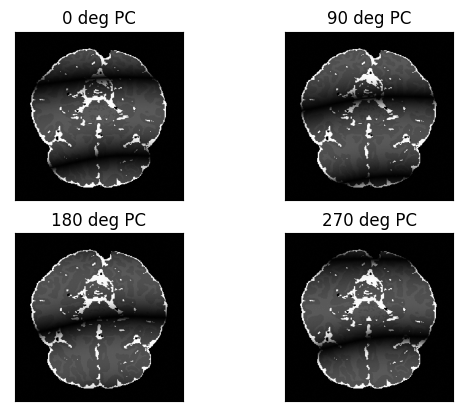

In [3]:
dataset = mssfp.generate_ssfp_dataset(
    phantom_type='brain', 
    npcs=4, 
    f=500, 
    alpha=np.deg2rad(60), 
    sigma=0.001, 
    data_indices=[(0, 2), (120,180)], 
    rotation=90,
    useRotate=True, 
    useDeform=True
)
mssfp.plot_dataset(dataset['M'], slice=0)


===== Running experiment: SyntheticBanding =====
Model path: D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding
Dataset path: D:/DeepSSFP/brain_phantom_dataaug_dataset.npy
Saved dataset found. Loading from file: D:/DeepSSFP/brain_phantom_dataaug_dataset.npy
Data shape: (120, 256, 256, 4)
Using same scaler for SyntheticBanding mode
Training data shape: (96, 256, 256, 4), (96, 256, 256, 4)
Input scaler stats: mean=0.0073, std=0.0701
Output scaler stats: mean=0.0073, std=0.0701
Selected indices: [ 7  3 12]
Figure size: (8, 6)


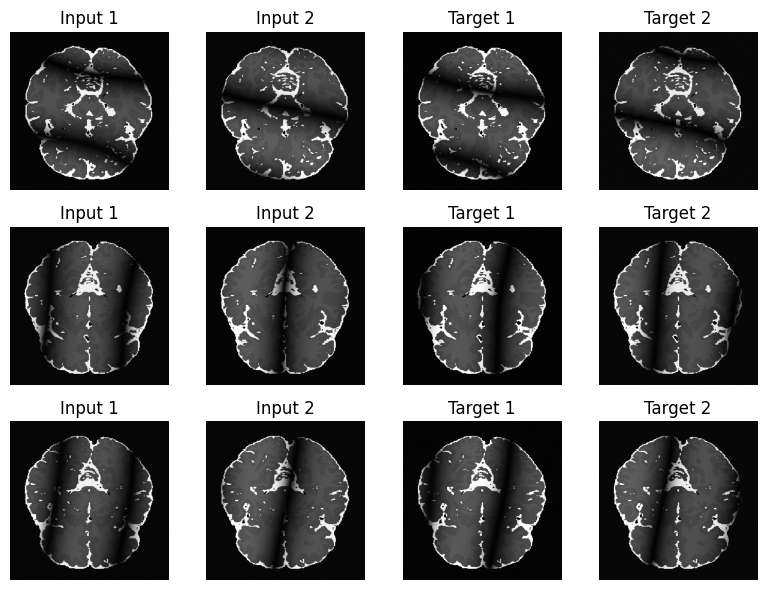

2025-03-25 23:38:17,227 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding



Loading pre-trained model...


2025-03-25 23:38:22,658 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding.keras
2025-03-25 23:38:22,659 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding_history.npz
2025-03-25 23:38:23,645 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding_training_history.png


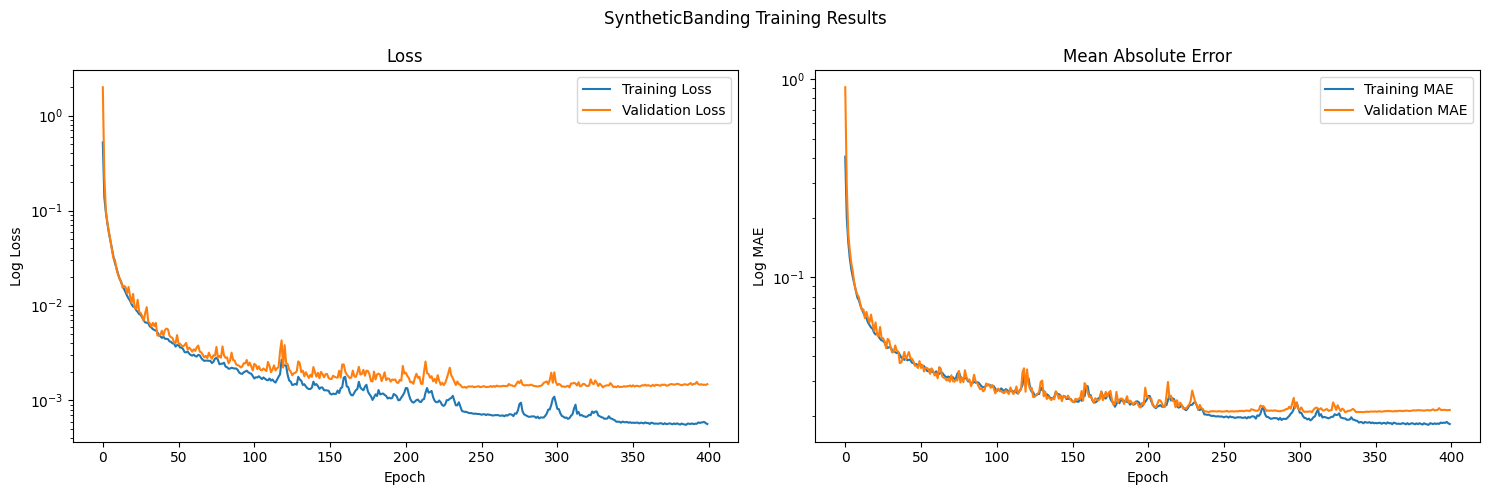

Using same scaler for SyntheticBanding mode


2025-03-25 23:38:25,898 - DeepSSFP - INFO - Making predictions on data with shape (24, 256, 256, 4)
2025-03-25 23:38:31,243 - DeepSSFP - INFO - Predictions complete. Output shape: (24, 256, 256, 4)


Selected indices: [17 13]
Figure size: (12, 4)
Image visualization saved to D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding_prediction_results.png


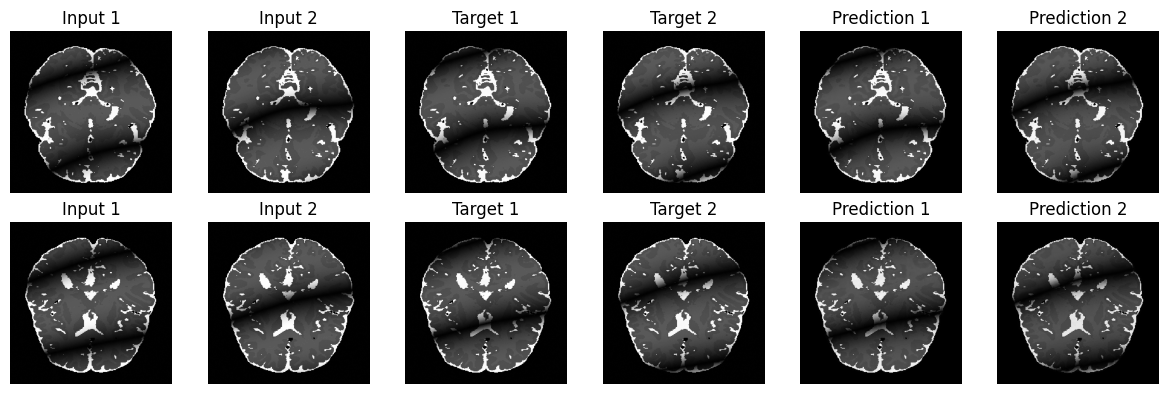

real/imag pairs -> complex
real/imag pairs -> complex
Target shape: (24, 256, 256), Prediction shape: (24, 256, 256)


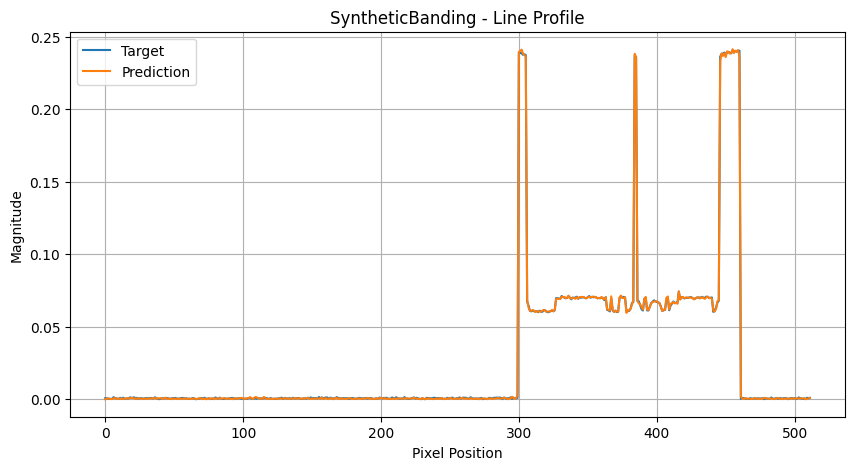


Evaluating band reduction...
Target shape: (24, 256, 256)
Prediction shape: (24, 256, 256)
Segmentation shape: (24, 256, 256)
Unique segmentation IDs: [0. 1. 2. 3.]
IDs to plot: [1. 2. 3.]
Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding_band_metrics_scatter


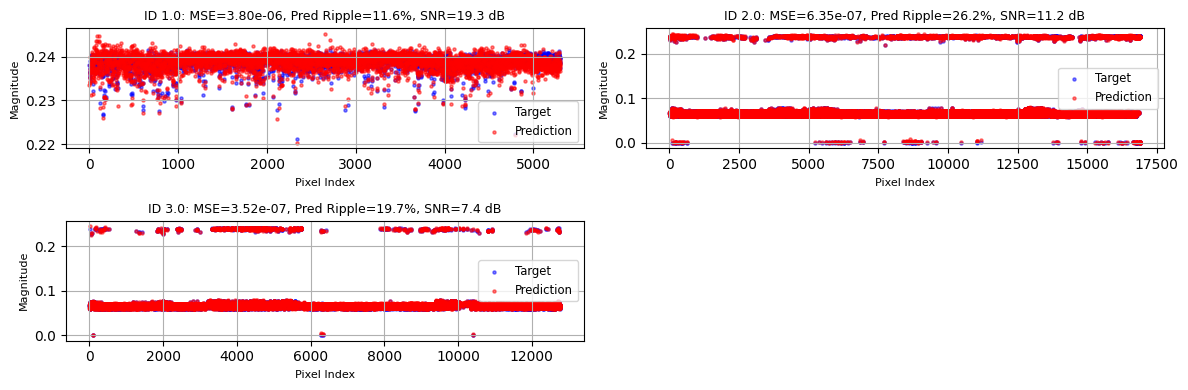

Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding_band_metrics


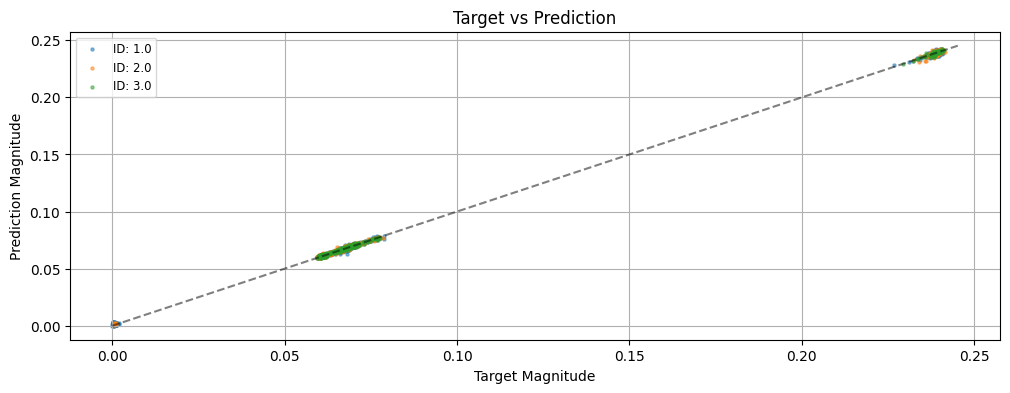


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=3.80e-06, MAE=1.12e-03, Pred Min=0.2181, Pred Max=0.2457, Pred Ripple=11.56%, Pred SNR=19.3 dB, Target Min=0.2219, Target Max=0.2416, Target Ripple=8.24%, Target SNR=19.3 dB, Samples=24, Pixels=5301
ID 2.0: MSE=6.35e-07, MAE=5.81e-04, Pred Min=0.0573, Pred Max=0.0738, Pred Ripple=26.24%, Pred SNR=11.2 dB, Target Min=0.0589, Target Max=0.0701, Target Ripple=17.85%, Target SNR=11.1 dB, Samples=24, Pixels=16904
ID 3.0: MSE=3.52e-07, MAE=4.61e-04, Pred Min=0.0666, Pred Max=0.0804, Pred Ripple=19.70%, Pred SNR=7.4 dB, Target Min=0.0679, Target Max=0.0791, Target Ripple=15.90%, Target SNR=7.4 dB, Samples=24, Pixels=12770

Calculating image quality metrics...

===== Image Quality Metrics =====

GLOBAL:
  MSE: 0.000001
  MAE: 0.000475
  PSNR: 63.047680
  SSIM: 0.999651
  NRMSE: 0.009377

SEGMENT_0.0:
  MSE: 0.000000
  MAE: 0.000325
  PSNR: 66.406906
  SSIM: nan
  NRMSE: 0.672875

SEGMENT_1.0:
  MSE: 0.000004
  MAE: 0.001118
  PS

In [ ]:
results = deepssfp.analysis.run_experiment(
    mode=deepssfp.DataMode.SuperFOV.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=False,
    #custom_dataset=dataset
)


===== Running experiment: BandRemoval:4 =====
Model path: D:/DeepSSFP/brain_phantom_dataaug_bandremoval_4
Dataset path: D:/DeepSSFP/brain_phantom_dataaug_dataset.npy
Data shape: (120, 256, 256, 4)
Training data shape: (96, 256, 256, 8), (96, 256, 256, 2)
Input scaler stats: mean=0.0073, std=0.0701
Output scaler stats: mean=0.0080, std=0.0550
Selected indices: [10  6 16]
Figure size: (10, 6)


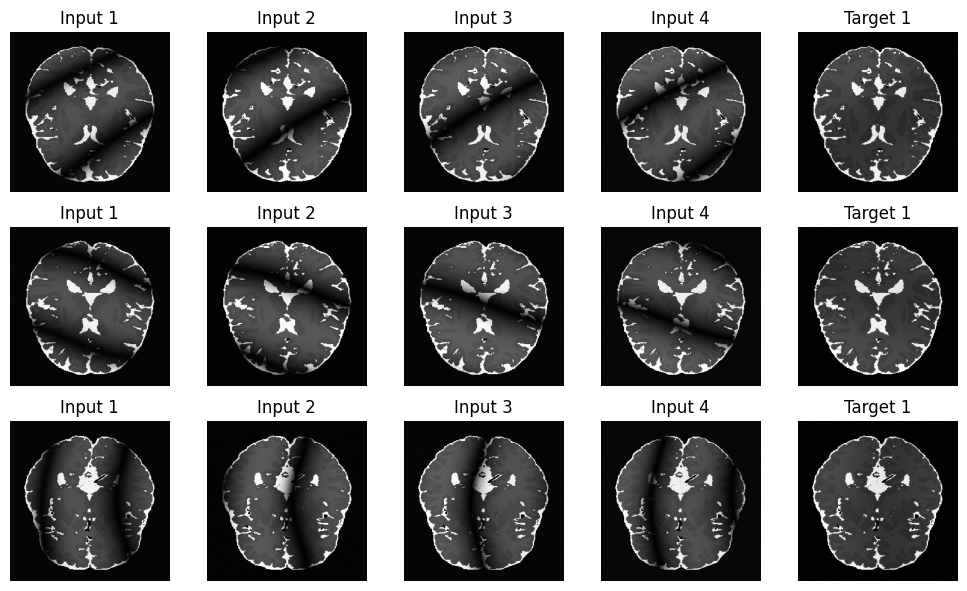

2025-03-24 23:56:39,127 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/brain_phantom_dataaug_bandremoval_4
2025-03-24 23:56:39,127 - DeepSSFP - INFO - Training DataSet: (96, 256, 256, 8) | (96, 256, 256, 2)
2025-03-24 23:56:39,128 - DeepSSFP - INFO - Test DataSet: (24, 256, 256, 8) | (24, 256, 256, 2)



Training model...


2025-03-24 23:56:39,771 - DeepSSFP - INFO - Creating new model with dimensions: 256x256x8→2


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 256, 256, 8) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 256, 256, 32) 2336        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 256, 256, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 256, 256, 32) 128         conv2d_1[0][0]                   
______________________________________________________________________________________________

2025-03-25 00:16:55,429 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/brain_phantom_dataaug_bandremoval_4.keras


1/1 [==============================] - 2s 2s/step - loss: 4.8226e-04 - mean_absolute_error: 0.0130


2025-03-25 00:16:57,851 - DeepSSFP - INFO - Training Complete. Loss: 0.0005, MAE: 0.0130
2025-03-25 00:16:57,852 - DeepSSFP - INFO - Time Elapsed: 1217.10 seconds
2025-03-25 00:16:58,892 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_bandremoval_4_training_history.png


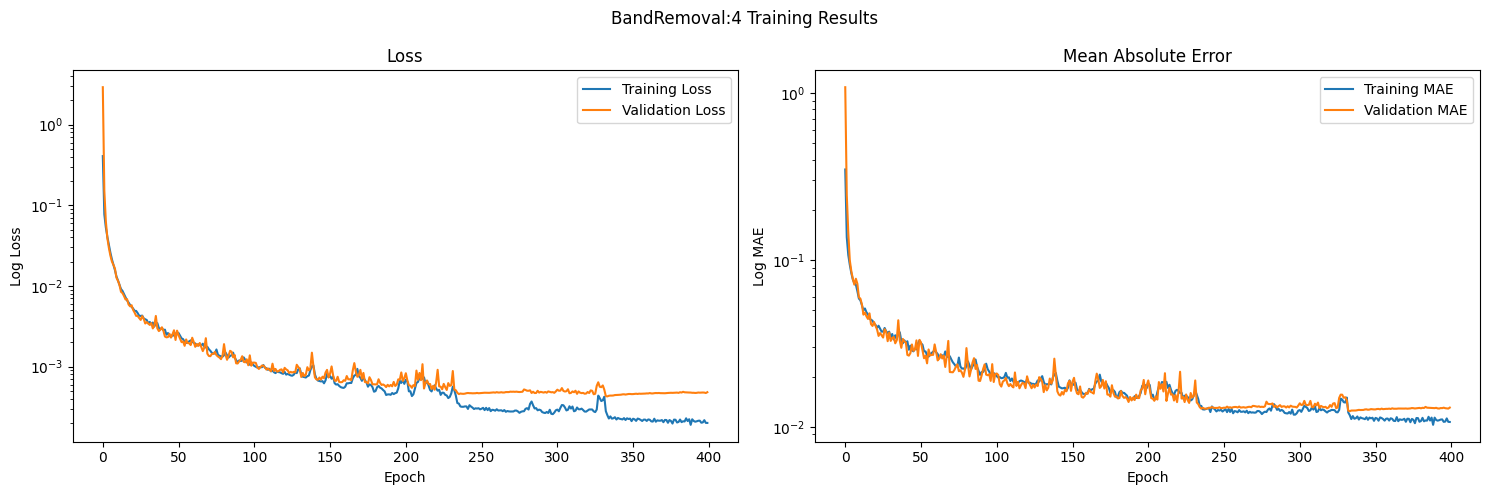

2025-03-25 00:17:25,512 - DeepSSFP - INFO - Making predictions on data with shape (24, 256, 256, 8)
2025-03-25 00:17:25,917 - DeepSSFP - INFO - Predictions complete. Output shape: (24, 256, 256, 2)


Selected indices: [ 1 16]
Figure size: (12, 4)
Image visualization saved to D:/DeepSSFP/brain_phantom_dataaug_bandremoval_4_prediction_results.png


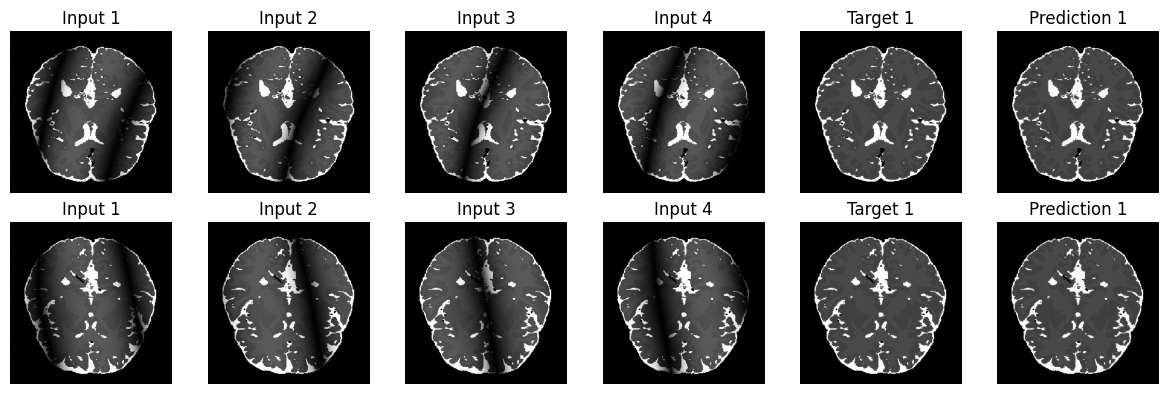

Target shape: (24, 256, 256), Prediction shape: (24, 256, 256)


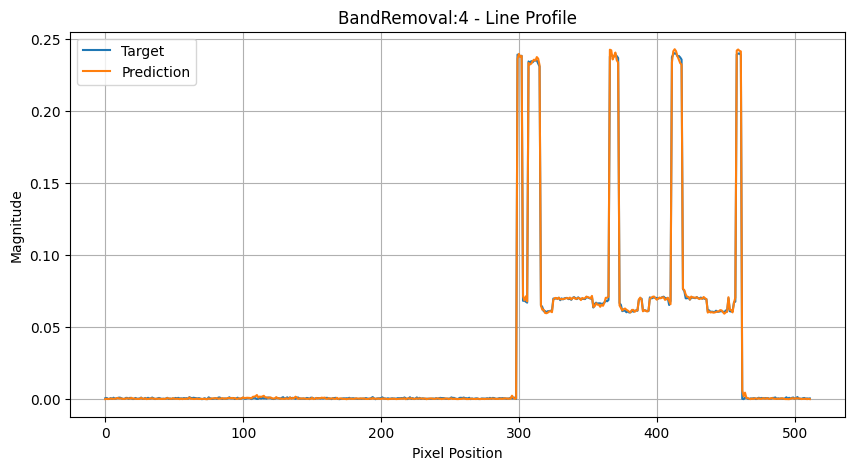


Evaluating band reduction...
Target shape: (24, 256, 256)
Prediction shape: (24, 256, 256)
Segmentation shape: (120, 256, 256)
Unique segmentation IDs: [0. 1. 2. 3.]
IDs to plot: [1. 2. 3.]
Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_bandremoval_4_band_metrics_scatter


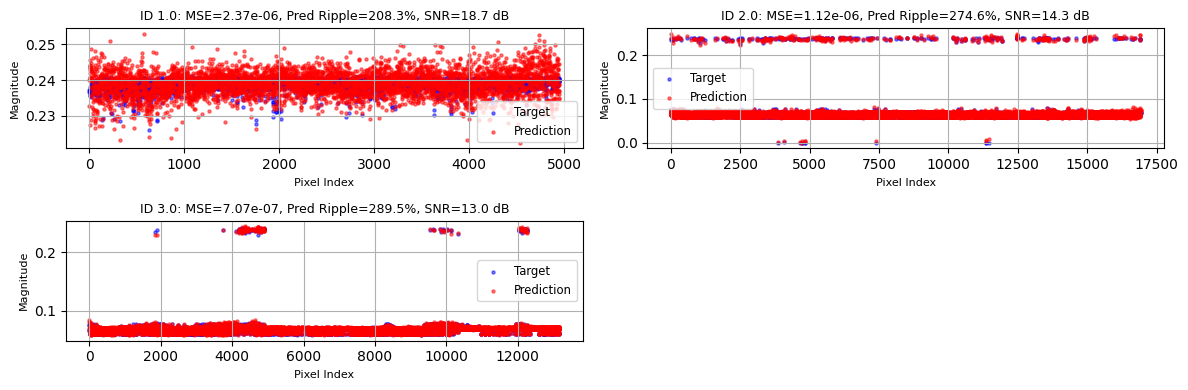

Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_bandremoval_4_band_metrics


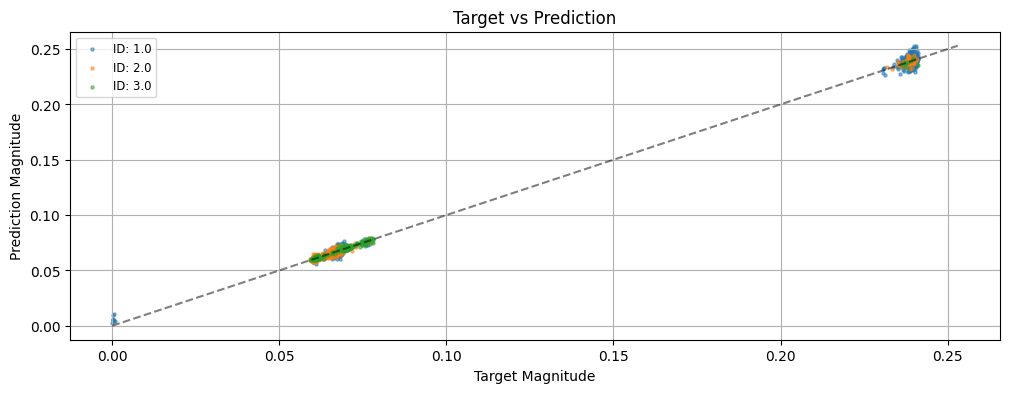


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=2.37e-06, MAE=1.05e-03, Pred Min=0.0187, Pred Max=0.2461, Pred Ripple=208.32%, Pred SNR=18.7 dB, Target Min=0.0187, Target Max=0.2415, Target Ripple=204.73%, Target SNR=18.7 dB, Samples=24, Pixels=4949
ID 2.0: MSE=1.12e-06, MAE=7.16e-04, Pred Min=0.0049, Pred Max=0.2317, Pred Ripple=274.62%, Pred SNR=14.3 dB, Target Min=0.0050, Target Max=0.2271, Target Ripple=268.91%, Target SNR=14.3 dB, Samples=24, Pixels=16924
ID 3.0: MSE=7.07e-07, MAE=5.76e-04, Pred Min=0.0061, Pred Max=0.2310, Pred Ripple=289.47%, Pred SNR=13.0 dB, Target Min=0.0057, Target Max=0.2277, Target Ripple=285.92%, Target SNR=13.0 dB, Samples=24, Pixels=13165

Calculating image quality metrics...

===== Image Quality Metrics =====

GLOBAL:
  MSE: 0.000001
  MAE: 0.000576
  PSNR: 61.515867
  SSIM: 0.999401
  NRMSE: 0.011127

SEGMENT_0.0:
  MSE: 0.000000
  MAE: 0.000430
  PSNR: 64.000609
  SSIM: nan
  NRMSE: 0.058336

SEGMENT_1.0:
  MSE: 0.000003
  MAE: 0.00

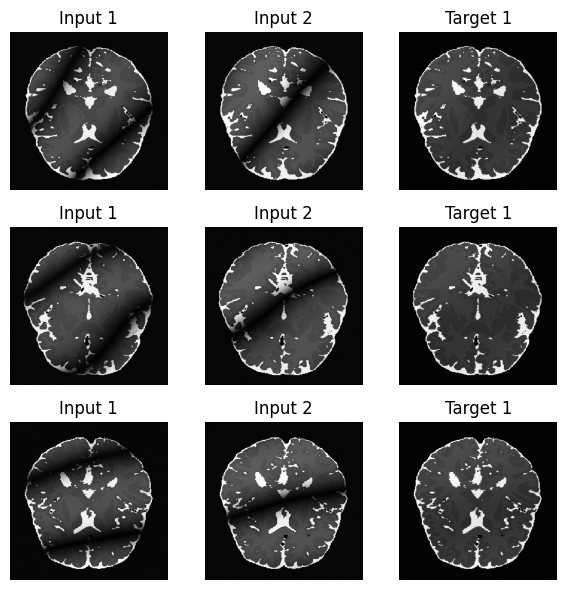

2025-03-25 00:18:01,032 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/brain_phantom_dataaug_bandremoval_2
2025-03-25 00:18:01,033 - DeepSSFP - INFO - Training DataSet: (96, 256, 256, 4) | (96, 256, 256, 2)
2025-03-25 00:18:01,033 - DeepSSFP - INFO - Test DataSet: (24, 256, 256, 4) | (24, 256, 256, 2)
2025-03-25 00:18:01,035 - DeepSSFP - INFO - Creating new model with dimensions: 256x256x4→2



Training model...
Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 256, 256, 4) 0                                            
__________________________________________________________________________________________________
conv2d_19 (Conv2D)              (None, 256, 256, 32) 1184        img[0][0]                        
__________________________________________________________________________________________________
conv2d_20 (Conv2D)              (None, 256, 256, 32) 9248        conv2d_19[0][0]                  
__________________________________________________________________________________________________
batch_normalization_9 (BatchNor (None, 256, 256, 32) 128         conv2d_20[0][0]                  
_________________________________________________________________________

2025-03-25 00:35:10,440 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/brain_phantom_dataaug_bandremoval_2.keras


1/1 [==============================] - 0s 372ms/step - loss: 0.0015 - mean_absolute_error: 0.0208


2025-03-25 00:35:11,163 - DeepSSFP - INFO - Training Complete. Loss: 0.0015, MAE: 0.0208
2025-03-25 00:35:11,164 - DeepSSFP - INFO - Time Elapsed: 1029.87 seconds
2025-03-25 00:35:12,187 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_bandremoval_2_training_history.png


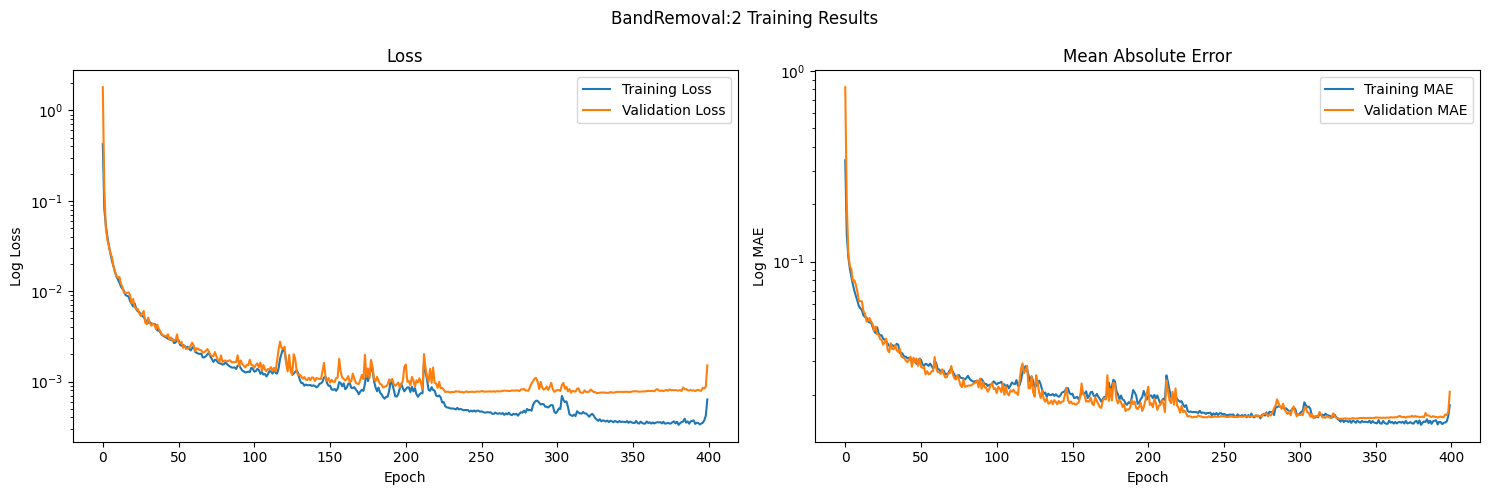

2025-03-25 00:35:37,392 - DeepSSFP - INFO - Making predictions on data with shape (24, 256, 256, 4)
2025-03-25 00:35:37,651 - DeepSSFP - INFO - Predictions complete. Output shape: (24, 256, 256, 2)


Selected indices: [16 21]
Figure size: (8, 4)
Image visualization saved to D:/DeepSSFP/brain_phantom_dataaug_bandremoval_2_prediction_results.png


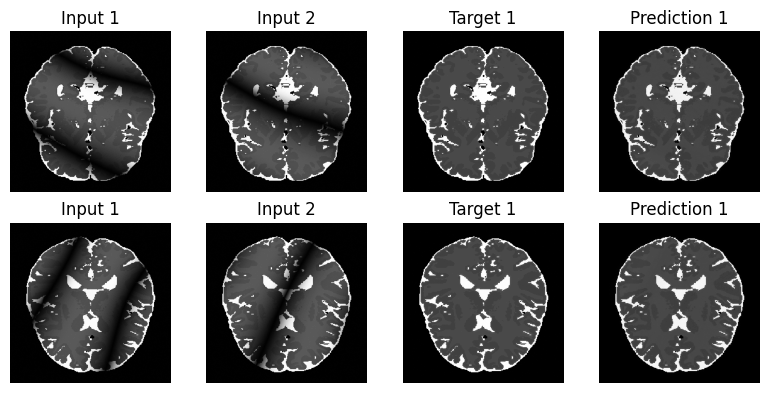

Target shape: (24, 256, 256), Prediction shape: (24, 256, 256)


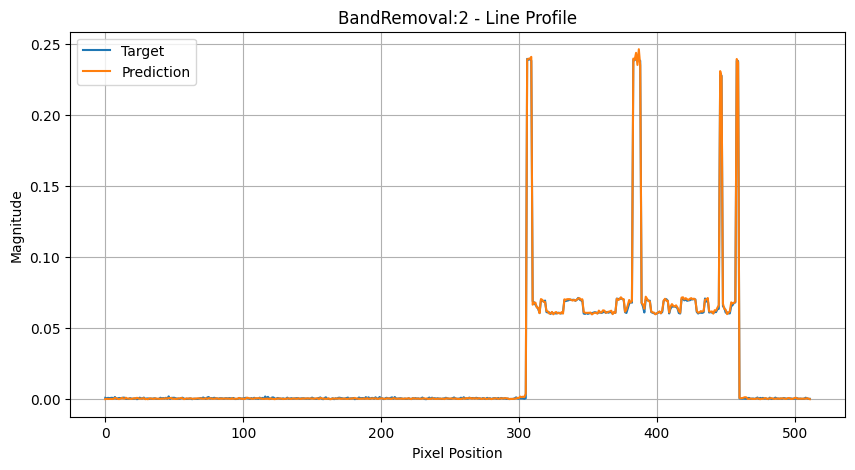


Evaluating band reduction...
Target shape: (24, 256, 256)
Prediction shape: (24, 256, 256)
Segmentation shape: (120, 256, 256)
Unique segmentation IDs: [0. 1. 2. 3.]
IDs to plot: [1. 2. 3.]
Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_bandremoval_2_band_metrics_scatter


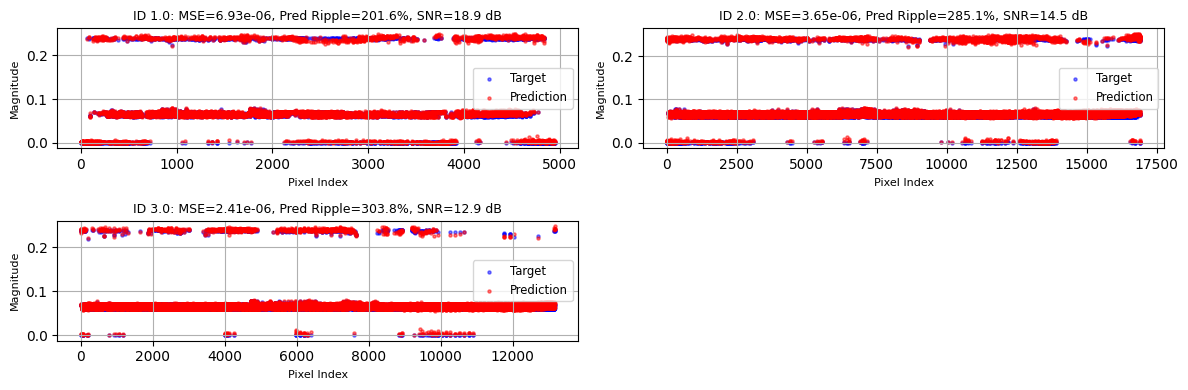

Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_bandremoval_2_band_metrics


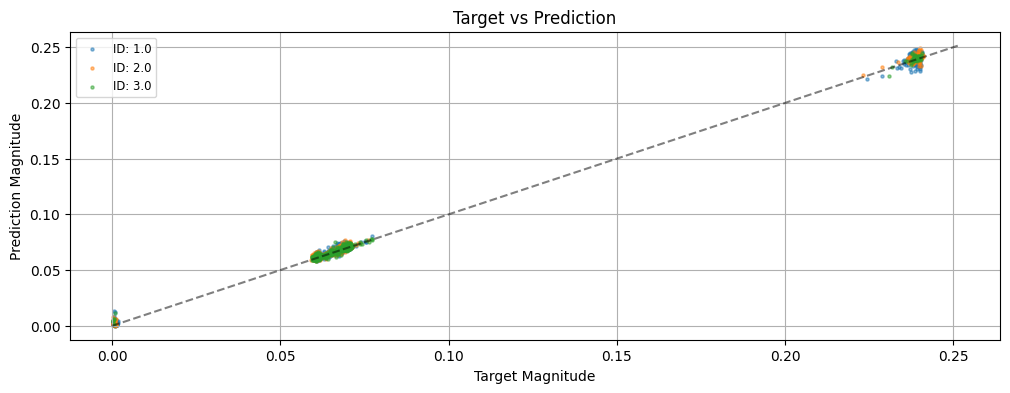


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=6.93e-06, MAE=1.93e-03, Pred Min=0.0094, Pred Max=0.2504, Pred Ripple=201.59%, Pred SNR=18.9 dB, Target Min=0.0094, Target Max=0.2415, Target Ripple=196.36%, Target SNR=18.9 dB, Samples=24, Pixels=4949
ID 2.0: MSE=3.65e-06, MAE=1.33e-03, Pred Min=0.0030, Pred Max=0.2425, Pred Ripple=285.07%, Pred SNR=14.5 dB, Target Min=0.0025, Target Max=0.2343, Target Ripple=278.56%, Target SNR=14.5 dB, Samples=24, Pixels=16924
ID 3.0: MSE=2.41e-06, MAE=1.04e-03, Pred Min=0.0062, Pred Max=0.2409, Pred Ripple=303.76%, Pred SNR=12.9 dB, Target Min=0.0054, Target Max=0.2345, Target Ripple=299.13%, Target SNR=12.8 dB, Samples=24, Pixels=13165

Calculating image quality metrics...

===== Image Quality Metrics =====

GLOBAL:
  MSE: 0.000002
  MAE: 0.000899
  PSNR: 56.660029
  SSIM: 0.999288
  NRMSE: 0.018821

SEGMENT_0.0:
  MSE: 0.000001
  MAE: 0.000456
  PSNR: 61.869893
  SSIM: nan
  NRMSE: 0.069750

SEGMENT_1.0:
  MSE: 0.000007
  MAE: 0.00

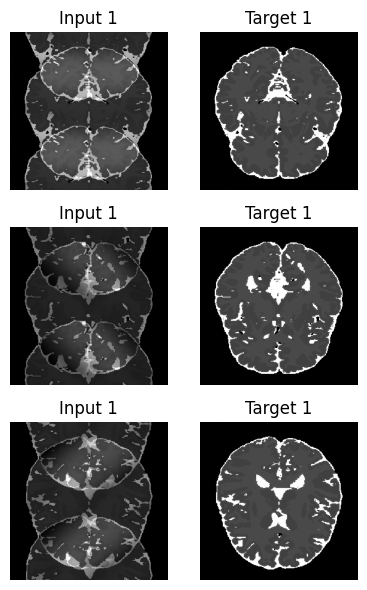

2025-03-25 00:36:11,602 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/brain_phantom_dataaug_superfov
2025-03-25 00:36:11,602 - DeepSSFP - INFO - Training DataSet: (96, 256, 256, 2) | (96, 256, 256, 2)
2025-03-25 00:36:11,603 - DeepSSFP - INFO - Test DataSet: (24, 256, 256, 2) | (24, 256, 256, 2)
2025-03-25 00:36:11,605 - DeepSSFP - INFO - Creating new model with dimensions: 256x256x2→2



Training model...
Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 256, 256, 2) 0                                            
__________________________________________________________________________________________________
conv2d_38 (Conv2D)              (None, 256, 256, 32) 608         img[0][0]                        
__________________________________________________________________________________________________
conv2d_39 (Conv2D)              (None, 256, 256, 32) 9248        conv2d_38[0][0]                  
__________________________________________________________________________________________________
batch_normalization_18 (BatchNo (None, 256, 256, 32) 128         conv2d_39[0][0]                  
_________________________________________________________________________

2025-03-25 00:51:42,679 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/brain_phantom_dataaug_superfov.keras


1/1 [==============================] - 0s 350ms/step - loss: 0.1235 - mean_absolute_error: 0.2216


2025-03-25 00:51:43,361 - DeepSSFP - INFO - Training Complete. Loss: 0.1235, MAE: 0.2216
2025-03-25 00:51:43,362 - DeepSSFP - INFO - Time Elapsed: 931.51 seconds
2025-03-25 00:51:44,235 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_superfov_training_history.png


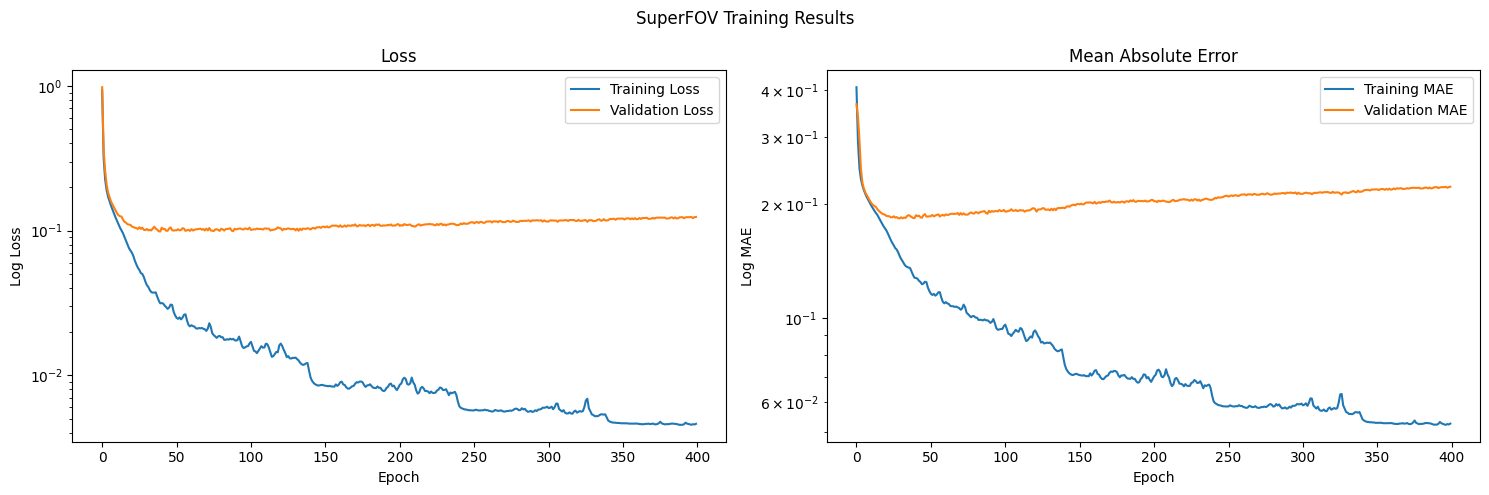

2025-03-25 00:52:09,543 - DeepSSFP - INFO - Making predictions on data with shape (24, 256, 256, 2)
2025-03-25 00:52:09,848 - DeepSSFP - INFO - Predictions complete. Output shape: (24, 256, 256, 2)


Selected indices: [21  3]
Figure size: (6, 4)
Image visualization saved to D:/DeepSSFP/brain_phantom_dataaug_superfov_prediction_results.png


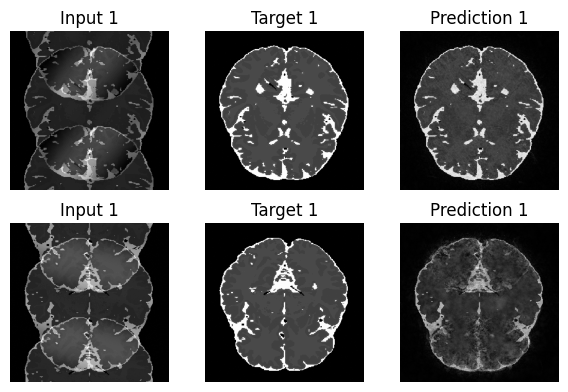

Target shape: (24, 256, 256), Prediction shape: (24, 256, 256)


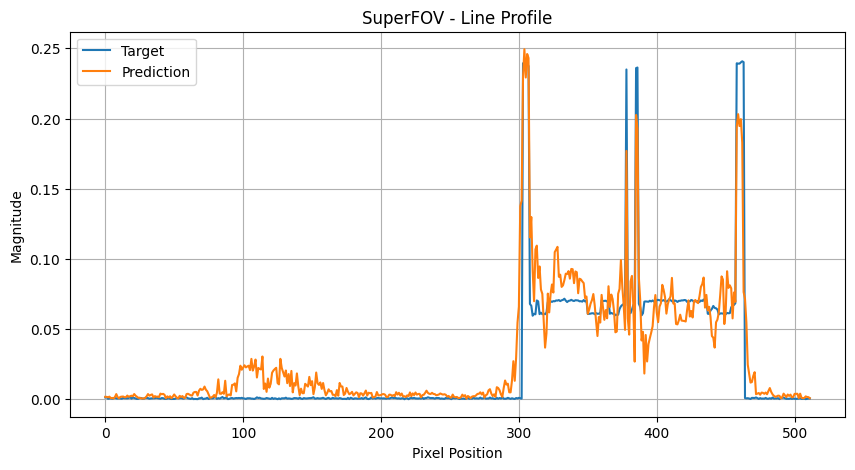


Evaluating band reduction...
Target shape: (24, 256, 256)
Prediction shape: (24, 256, 256)
Segmentation shape: (120, 256, 256)
Unique segmentation IDs: [0. 1. 2. 3.]
IDs to plot: [1. 2. 3.]
Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_superfov_band_metrics_scatter


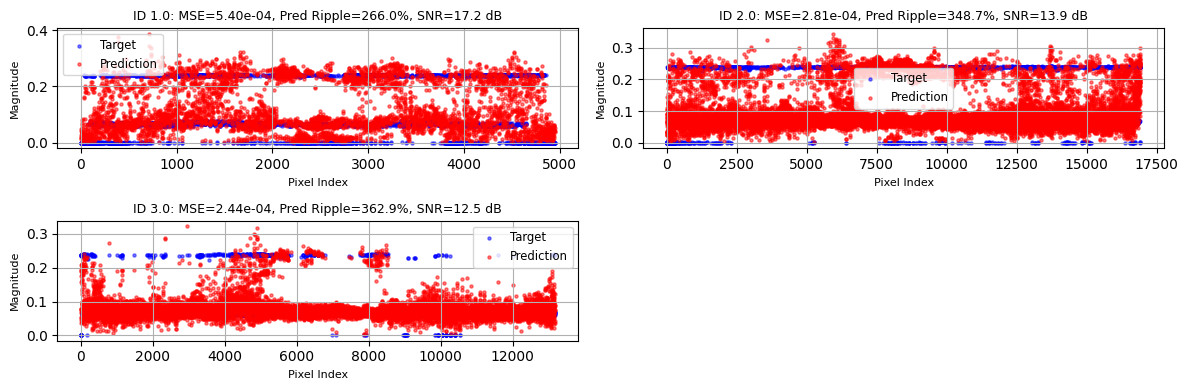

Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_superfov_band_metrics


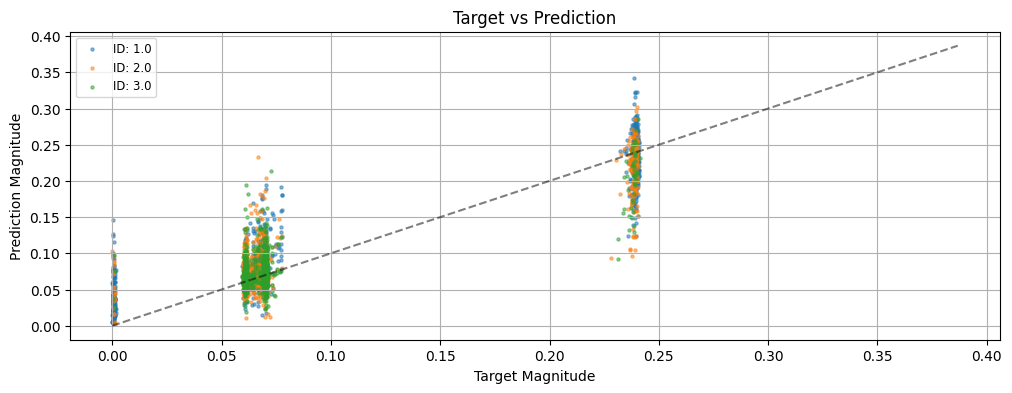


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=5.40e-04, MAE=1.42e-02, Pred Min=0.0009, Pred Max=0.3054, Pred Ripple=265.96%, Pred SNR=17.2 dB, Target Min=0.0000, Target Max=0.2414, Target Ripple=218.59%, Target SNR=17.2 dB, Samples=24, Pixels=4949
ID 2.0: MSE=2.81e-04, MAE=1.01e-02, Pred Min=0.0017, Pred Max=0.2992, Pred Ripple=348.71%, Pred SNR=13.9 dB, Target Min=0.0001, Target Max=0.2414, Target Ripple=288.52%, Target SNR=13.8 dB, Samples=24, Pixels=16924
ID 3.0: MSE=2.44e-04, MAE=9.25e-03, Pred Min=0.0039, Pred Max=0.2929, Pred Ripple=362.88%, Pred SNR=12.5 dB, Target Min=0.0025, Target Max=0.2413, Target Ripple=303.73%, Target SNR=12.5 dB, Samples=24, Pixels=13165

Calculating image quality metrics...

===== Image Quality Metrics =====

GLOBAL:
  MSE: 0.000187
  MAE: 0.007408
  PSNR: 39.791839
  SSIM: 0.906768
  NRMSE: 0.150433

SEGMENT_0.0:
  MSE: 0.000068
  MAE: 0.004301
  PSNR: 43.604016
  SSIM: nan
  NRMSE: 0.243314

SEGMENT_1.0:
  MSE: 0.000530
  MAE: 0.01

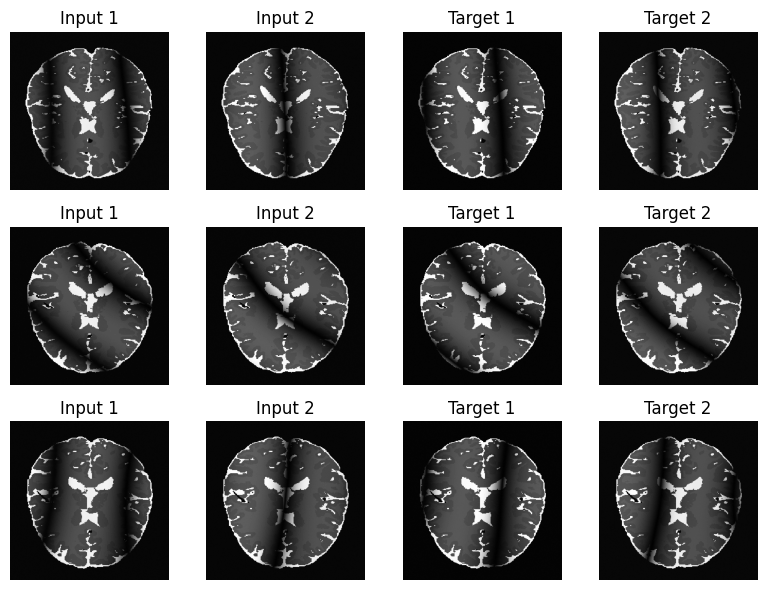

2025-03-25 00:52:21,855 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding
2025-03-25 00:52:21,855 - DeepSSFP - INFO - Training DataSet: (96, 256, 256, 4) | (96, 256, 256, 4)
2025-03-25 00:52:21,856 - DeepSSFP - INFO - Test DataSet: (24, 256, 256, 4) | (24, 256, 256, 4)
2025-03-25 00:52:21,858 - DeepSSFP - INFO - Creating new model with dimensions: 256x256x4→4



Training model...
Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 256, 256, 4) 0                                            
__________________________________________________________________________________________________
conv2d_57 (Conv2D)              (None, 256, 256, 32) 1184        img[0][0]                        
__________________________________________________________________________________________________
conv2d_58 (Conv2D)              (None, 256, 256, 32) 9248        conv2d_57[0][0]                  
__________________________________________________________________________________________________
batch_normalization_27 (BatchNo (None, 256, 256, 32) 128         conv2d_58[0][0]                  
_________________________________________________________________________

2025-03-25 01:10:42,551 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding.keras


1/1 [==============================] - 0s 366ms/step - loss: 0.0015 - mean_absolute_error: 0.0214


2025-03-25 01:10:43,283 - DeepSSFP - INFO - Training Complete. Loss: 0.0015, MAE: 0.0214
2025-03-25 01:10:43,284 - DeepSSFP - INFO - Time Elapsed: 1101.16 seconds
2025-03-25 01:10:44,126 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding_training_history.png


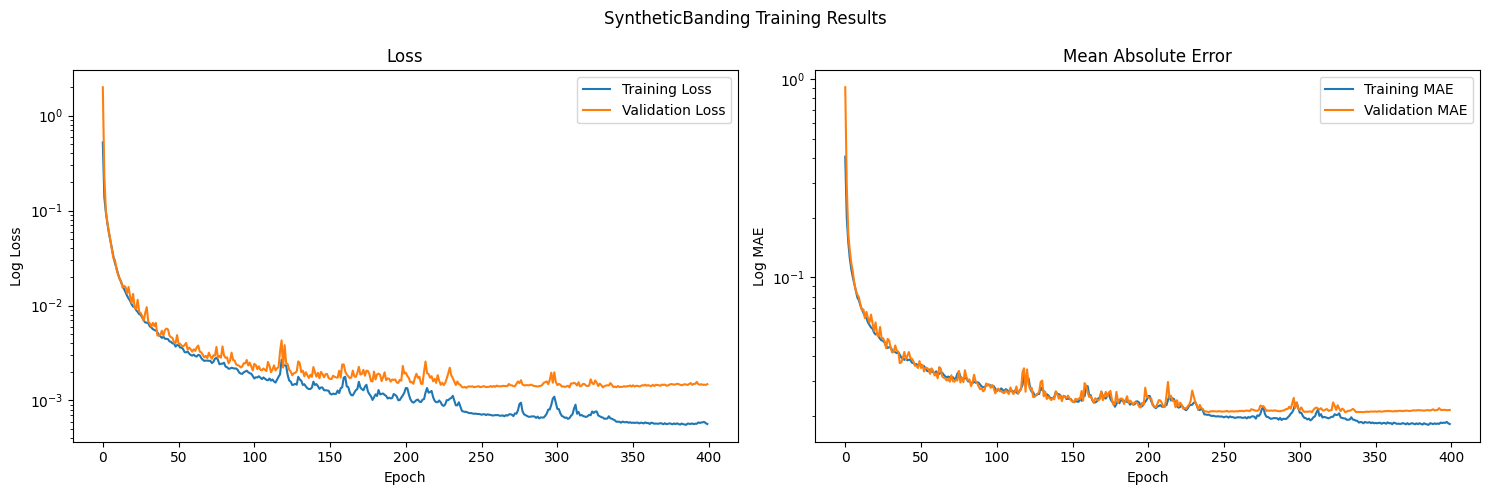

Using same scaler for SyntheticBanding mode


2025-03-25 01:10:46,220 - DeepSSFP - INFO - Making predictions on data with shape (24, 256, 256, 4)
2025-03-25 01:10:46,431 - DeepSSFP - INFO - Predictions complete. Output shape: (24, 256, 256, 4)


Selected indices: [ 7 11]
Figure size: (12, 4)
Image visualization saved to D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding_prediction_results.png


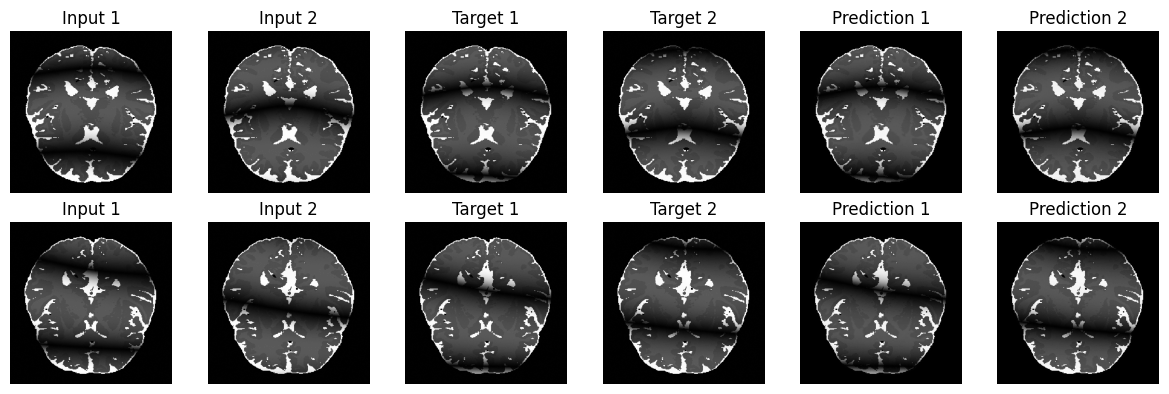

real/imag pairs -> complex
real/imag pairs -> complex
Target shape: (24, 256, 256), Prediction shape: (24, 256, 256)


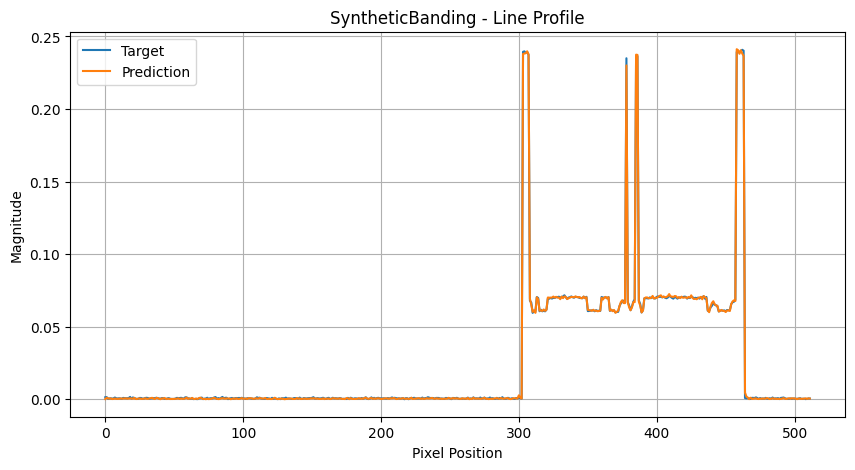


Evaluating band reduction...
Target shape: (24, 256, 256)
Prediction shape: (24, 256, 256)
Segmentation shape: (120, 256, 256)
Unique segmentation IDs: [0. 1. 2. 3.]
IDs to plot: [1. 2. 3.]
Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding_band_metrics_scatter


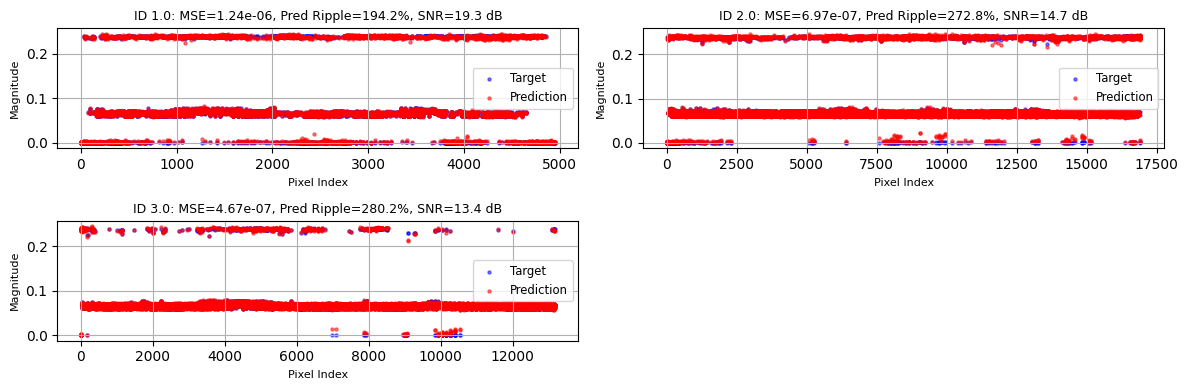

Training history plot saved to D:/DeepSSFP/brain_phantom_dataaug_syntheticbanding_band_metrics


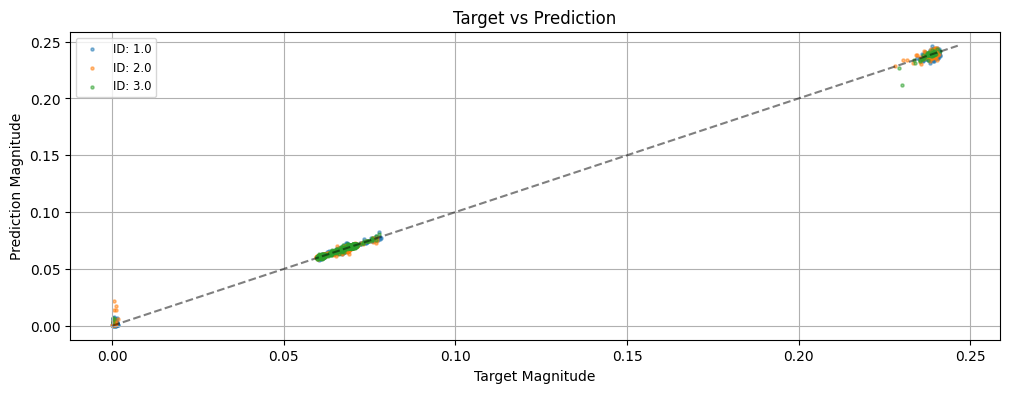


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=1.24e-06, MAE=7.90e-04, Pred Min=0.0187, Pred Max=0.2447, Pred Ripple=194.21%, Pred SNR=19.3 dB, Target Min=0.0186, Target Max=0.2415, Target Ripple=191.73%, Target SNR=19.3 dB, Samples=24, Pixels=4949
ID 2.0: MSE=6.97e-07, MAE=5.94e-04, Pred Min=0.0051, Pred Max=0.2302, Pred Ripple=272.80%, Pred SNR=14.7 dB, Target Min=0.0050, Target Max=0.2271, Target Ripple=269.37%, Target SNR=14.6 dB, Samples=24, Pixels=16924
ID 3.0: MSE=4.67e-07, MAE=5.08e-04, Pred Min=0.0109, Pred Max=0.2299, Pred Ripple=280.17%, Pred SNR=13.4 dB, Target Min=0.0107, Target Max=0.2277, Target Ripple=278.02%, Target SNR=13.4 dB, Samples=24, Pixels=13165

Calculating image quality metrics...

===== Image Quality Metrics =====

GLOBAL:
  MSE: 0.000000
  MAE: 0.000465
  PSNR: 63.417056
  SSIM: 0.999668
  NRMSE: 0.008599

SEGMENT_0.0:
  MSE: 0.000000
  MAE: 0.000329
  PSNR: 66.461629
  SSIM: nan
  NRMSE: 0.014713

SEGMENT_1.0:
  MSE: 0.000001
  MAE: 0.00

{'BandRemoval:4': {'mode': 'BandRemoval:4',
  'model': <tensorflow.python.keras.engine.functional.Functional at 0x26e8946f9d0>,
  'dataset': dataset.Dataset(BandRemoval:4),
  'predictions': array([[[ 5.98486513e-05-1.56505313e-03j,
            4.62859403e-04+6.29723072e-05j,
           -9.26489010e-05+5.91945834e-04j, ...,
            3.40186059e-04-1.50189735e-04j,
           -2.46506184e-04-2.33665109e-04j,
            1.61333894e-03+2.55411351e-03j],
          [-4.25553881e-04+9.12211370e-04j,
           -1.14096329e-04+2.52817292e-04j,
            6.82759099e-04+1.40780583e-04j, ...,
           -3.37744132e-05+3.87988985e-05j,
            4.71668784e-04-6.34423457e-04j,
           -6.19128346e-04+8.16099346e-04j],
          [-7.15311617e-05-4.80091199e-04j,
            1.01314858e-04-6.27549365e-04j,
           -3.75539996e-04-4.85042110e-05j, ...,
            2.13754829e-04-7.11352564e-04j,
            3.23261134e-04+4.10133041e-04j,
           -3.66826542e-04-1.15402974e-04j],
  

In [4]:
deepssfp.analysis.run_all_experiments(
    modes=modes,
    model_name=model_name,
    model_dir=model_dir,
    train_models=True,  # Set to False to use pre-trained models
    custom_dataset=dataset
)

In [5]:
# Compare experiment results
deepssfp.analysis.compare_experiments(
    modes=modes,
    model_name=model_name,
    model_dir=model_dir
)

Comparison plots saved to D:/DeepSSFP/brain_phantom_dataaug_comparison_plots

===== Experiment Comparison Summary =====
Model: brain_phantom_dataaug
Modes: BandRemoval:4, BandRemoval:2, SuperFOV, SyntheticBanding

Global Image Quality Metrics:
Metric  BandRemoval:4  BandRemoval:2  SuperFOV  SyntheticBanding
   MSE   8.145382e-07       0.000002  0.000187      4.729973e-07
   MAE   5.758606e-04       0.000899  0.007408      4.652394e-04
  PSNR   6.151587e+01      56.660029 39.791839      6.341706e+01
  SSIM   9.994012e-01       0.999288  0.906768      9.996680e-01
 NRMSE   1.112709e-02       0.018821  0.150433      8.599425e-03

Best Mode by Metric:
  MSE: SyntheticBanding (0.000000)
  MAE: SyntheticBanding (0.000465)
  PSNR: SyntheticBanding (63.417056)
  SSIM: SyntheticBanding (0.999668)
  NRMSE: SyntheticBanding (0.008599)

Summary saved to D:/DeepSSFP//brain_phantom_dataaug_metrics_summary.csv


<Figure size 1400x800 with 0 Axes>